# Neural Networks (Deep Learning)

## The neural network model

In [53]:
import numpy as np
import pandas as pd
import mglearn
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

Text(0, 0.5, 'relu(x), tanh(x)')

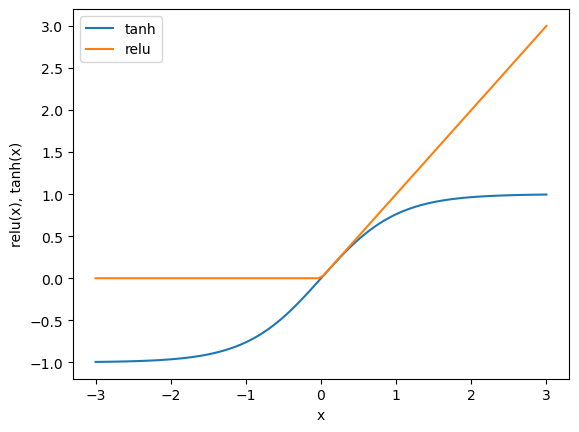

In [12]:
line = np.linspace(-3, 3, 100)
plt.plot(line, np.tanh(line), label='tanh')
plt.plot(line, np.maximum(line, 0), label='relu')
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('relu(x), tanh(x)')

Text(0, 0.5, 'Feature 1')

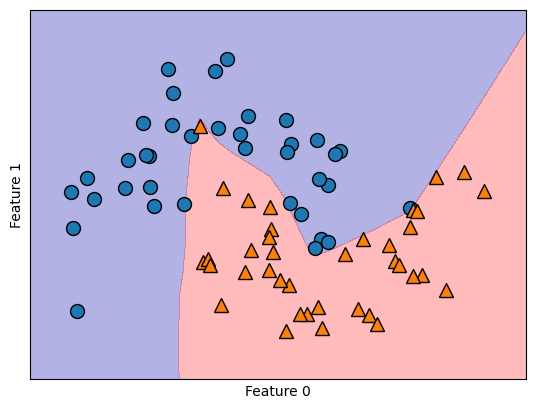

In [45]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

x, y = make_moons(n_samples=100, noise=.25, random_state=3)

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,
                                                   random_state=42)

mlp = MLPClassifier(solver='lbfgs', random_state=0).fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

Text(0, 0.5, 'Feature 1')

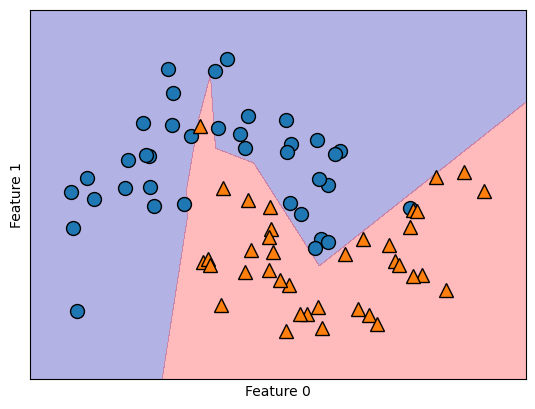

In [19]:
mlp = MLPClassifier(solver='lbfgs', max_iter=100000, random_state=0, hidden_layer_sizes=[10])
mlp.fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

Text(0, 0.5, 'Feature 1')

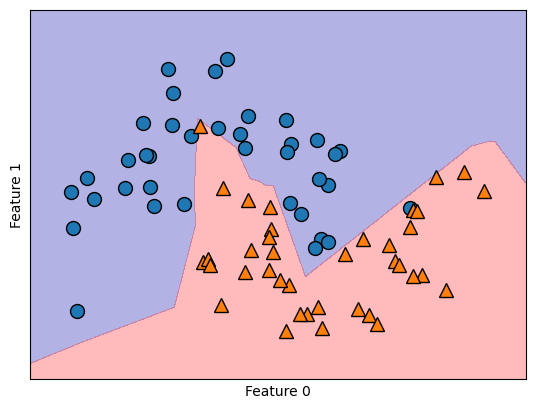

In [20]:
# using two hidden layers, with 10 units each
mlp = MLPClassifier(solver='lbfgs', random_state=0,
                   hidden_layer_sizes=[10, 10])
mlp.fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

Text(0, 0.5, 'Feature 1')

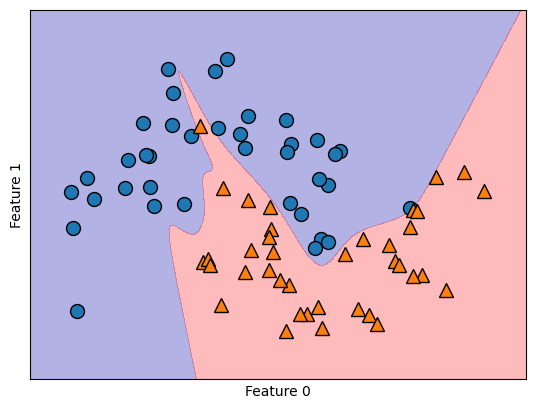

In [46]:
# using two hidden layers, with 10 each, now with tanh nonlinearity
mlp = MLPClassifier(solver='lbfgs', activation='tanh',
                   random_state=0, hidden_layer_sizes=[10, 10])
mlp.fit(x_train,y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

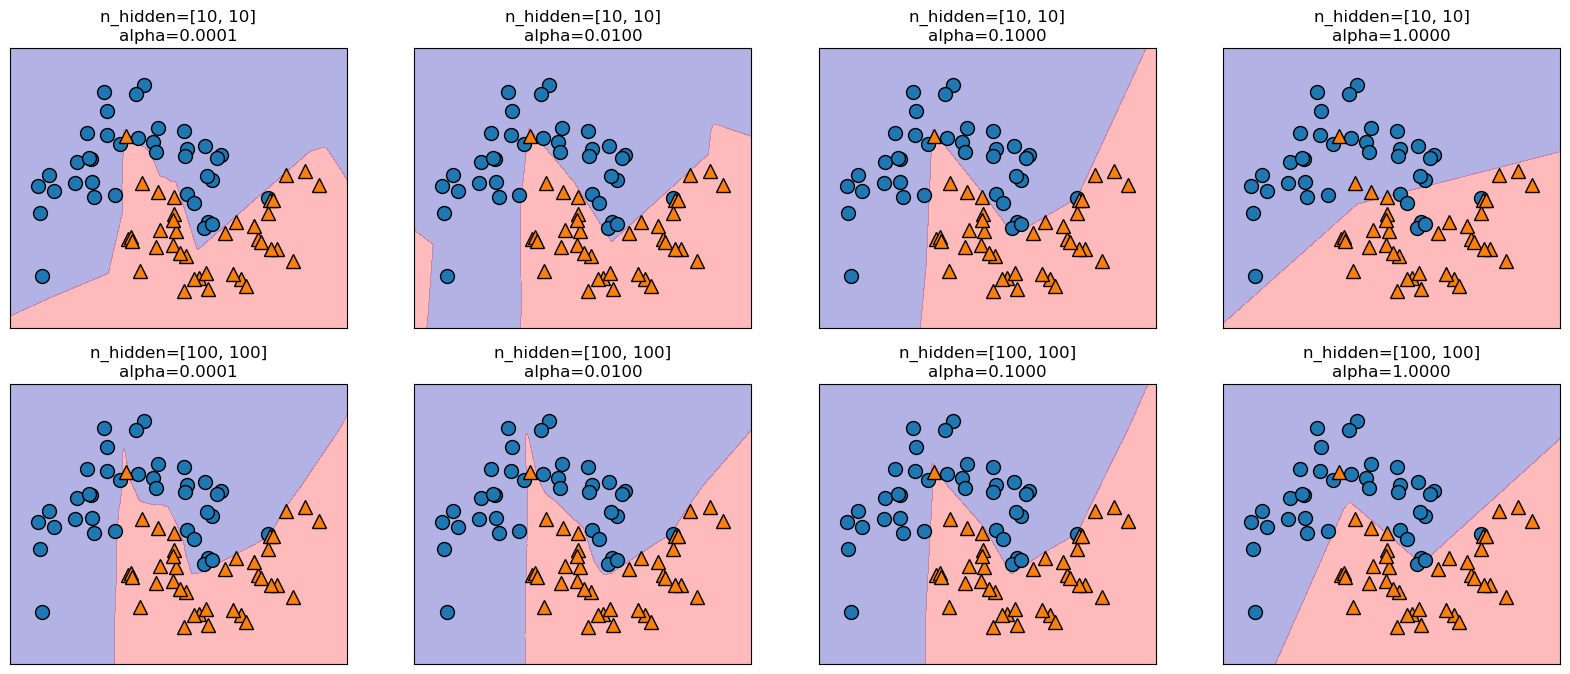

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for axx, n_hidden_nodes in zip(axes, [10, 100]):
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        mlp = MLPClassifier(solver='lbfgs', max_iter=100000, random_state=0,
                           hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes],
                           alpha=alpha)
        mlp.fit(x_train, y_train)
        mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3, ax=ax)
        mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train, ax=ax)
        ax.set_title('n_hidden=[{}, {}]\nalpha={:.4f}'.format(
                    n_hidden_nodes, n_hidden_nodes, alpha))
        

In [57]:
print('Cancer data per-feature maxima:\n{}'.format(cancer.data.max(axis=0)))

Cancer data per-feature maxima:
[2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]


In [61]:
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

mlp = MLPClassifier(random_state=0)
mlp.fit(x_train, y_train)

print('Accuracy on training set: {:.3f}'.format(mlp.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(mlp.score(x_test, y_test)))

Accuracy on training set: 0.927
Accuracy on test set: 0.930


In [62]:
# compute the mean value per feature on the training set
mean_on_train =x_train.mean(axis=0)

# compute the standard devoation of each feature on the training set
std_on_train = x_train.std(axis=0)

# substract the mean, and scale by inverse standard deviation
# afterward, mean=0 and std=1
x_train_scaled = (x_train - mean_on_train) / std_on_train

# use THE SAME transformation (using training mean and std) on the test set
x_test_scaled = (x_test - mean_on_train) / std_on_train

mlp = MLPClassifier(random_state=0)
mlp.fit(x_train, y_train)

print('Accuracy on training set: {:.3f}'.format(
    mlp.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(
    mlp.score(x_test, y_test)))

Accuracy on training set: 0.927
Accuracy on test set: 0.930


In [64]:
mlp = MLPClassifier(max_iter=100, random_state=0)
mlp.fit(x_train, y_train)
print('Accuracy on training set: {:.3f}'.format(
    mlp.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(
    mlp.score(x_test, y_test)))

Accuracy on training set: 0.927
Accuracy on test set: 0.930


In [65]:
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(x_train, y_train)

print('Accuracy on training set: {:.3f}'.format(
    mlp.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(mlp.score(x_test, y_test)))

Accuracy on training set: 0.925
Accuracy on test set: 0.923


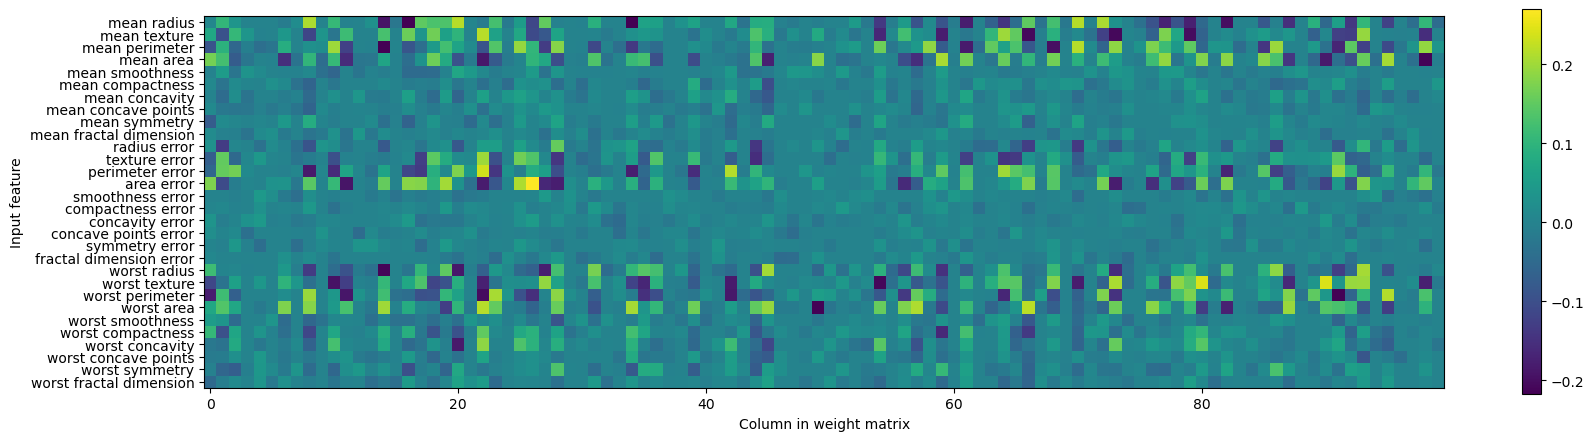

In [75]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel('Column in weight matrix')
plt.ylabel('Input feature')
plt.colorbar()